Accuracy on linear blobs: 100.00%


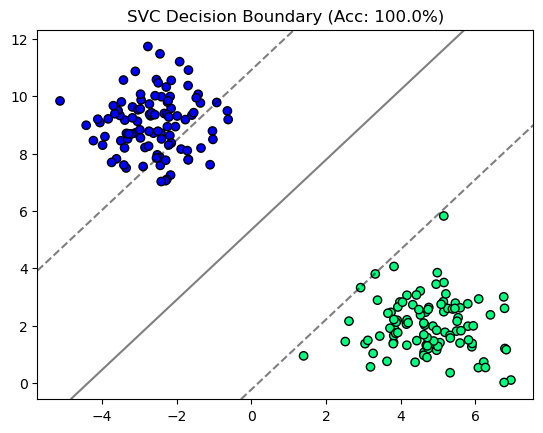

In [4]:
import numpy as np
from sklearn.datasets import make_blobs, make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from svm import SVC_BASE 

# Здесь предполагается, что твой класс называется MySVC
# from your_library import MySVC 

def test_svm():
    # 1. Генерация линейно разделимых данных
    X, y = make_blobs(n_samples=200, centers=2, random_state=42, cluster_std=1.0)
    
    # SVC ожидает метки {-1, 1}
    y = np.where(y <= 0, -1, 1)
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Инициализация и обучение твоей модели
    # Настраиваем параметры под конкретную задачу
    model = SVC_BASE(C=0.1, max_iter=1000, batch_size=32)
    model.fit(X_train, y_train)

    # 3. Предсказание
    y_pred = model.predict(X_test)
    
    # 4. Проверка точности
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy on linear blobs: {acc * 100:.2f}%")

    # Визуализация разделяющей прямой
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k')
    
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    
    # Считаем решающую функцию: Z = Xw + b
    Z = (xy @ model.coef_ + model.intercept_).reshape(XX.shape)

    # Рисуем разделяющую плоскость и зазоры
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    plt.title(f"SVC Decision Boundary (Acc: {acc*100:.1f}%)")
    plt.show()

if __name__ == "__main__":
    test_svm()

Количество опорных векторов: 18
Точность (Accuracy): 100.00%


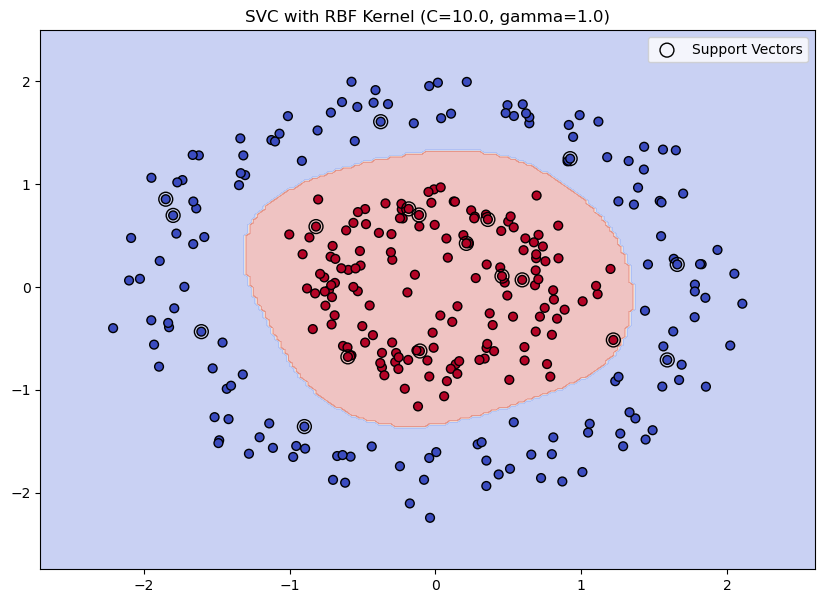

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from svm import SVC

# 1. Генерация данных (кольца)
X, y = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=42)
y = np.where(y == 0, -1, 1)

# 2. Масштабирование (Scaler)
# Это сделает среднее = 0, а дисперсию = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение на трейн и тест
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 3. Обучение твоего классификатора
# Ставим C побольше, чтобы модель активнее исправляла ошибки,
# и gamma=1.0, чтобы "купола" ядра были адекватного размера
model = SVC(max_iter=1000, C=10.0, tol=1e-3, kernel='rbf', gamma=1.0)
model.fit(X_train, y_train)

# 4. Проверка
y_pred = model.predict(X_test)
print(f"Количество опорных векторов: {np.sum(model.alpha > 1e-5)}")
print(f"Точность (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%")

# 5. Визуализация
def plot_svc_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.figure(figsize=(10, 7))
    plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k', s=40)
    
    # Выделяем опорные векторы, если они есть
    sv_idx = np.where(model.alpha > 1e-5)[0]
    if len(sv_idx) > 0:
        plt.scatter(X[sv_idx, 0], X[sv_idx, 1], s=100, facecolors='none', 
                    edgecolors='black', label='Support Vectors')
    
    plt.title(f"SVC with RBF Kernel (C={model.C}, gamma={model.gamma})")
    plt.legend()
    plt.show()

plot_svc_decision_boundary(X_scaled, y, model)